In [1]:
import sys
import torch

print("Python Executable:", sys.executable)
print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("MPS Available:", torch.backends.mps.is_available())

Python Executable: /Users/omvdangi/MetaFailurePredictor/venv/bin/python
Python Version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 21.0.0 (clang-2100.0.123.102)]
PyTorch Version: 2.12.0
MPS Available: True


In [2]:
from torchvision.datasets import CIFAR10

train_dataset = CIFAR10(
    root="../data",
    train=True,
    download=True
)

test_dataset = CIFAR10(
    root="../data",
    train=False,
    download=True
)

print("Train Samples:", len(train_dataset))
print("Test Samples:", len(test_dataset))

100%|██████████| 170M/170M [04:43<00:00, 601kB/s]  


Train Samples: 50000
Test Samples: 10000


In [3]:
classes = train_dataset.classes

print("Classes:")
for i, cls in enumerate(classes):
    print(f"{i}: {cls}")

Classes:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


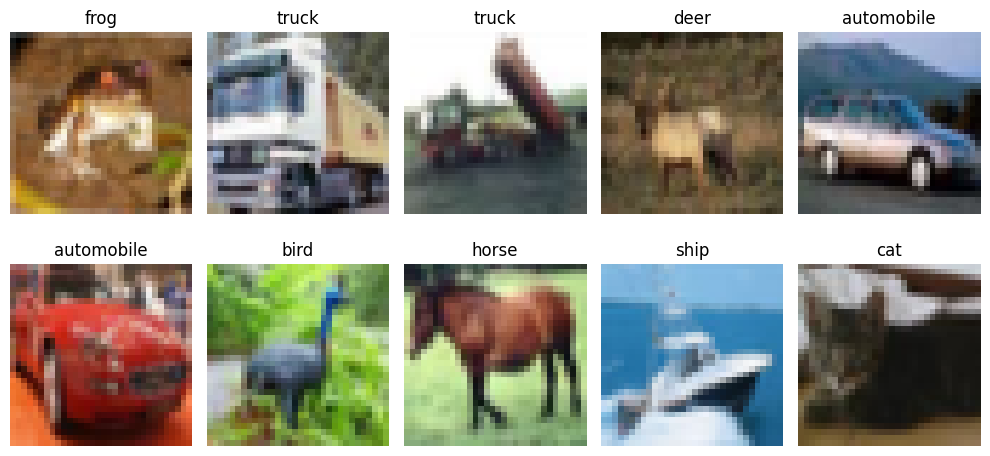

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    image, label = train_dataset[i]

    ax = axes[i // 5, i % 5]
    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import CIFAR10

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

train_dataset = CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=transform_train
)

test_dataset = CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 391
Test batches: 79


In [7]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using Device:", device)

Using Device: mps


In [8]:
import torch.nn as nn
from torchvision.models import resnet18

model = resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    10
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss Function: CrossEntropyLoss()
Optimizer: Adam


In [10]:
def evaluate(model, dataloader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [11]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1}/{epochs}"
        )

    test_acc = evaluate(
        model,
        test_loader
    )

    print(
        f"Epoch {epoch+1}: "
        f"Loss={running_loss/len(train_loader):.4f} "
        f"Test Accuracy={test_acc:.2f}%"
    )

Epoch 1/5: 100%|██████████| 391/391 [00:20<00:00, 18.63it/s]


Epoch 1: Loss=1.5505 Test Accuracy=54.74%


Epoch 2/5: 100%|██████████| 391/391 [00:15<00:00, 25.42it/s]


Epoch 2: Loss=1.1988 Test Accuracy=62.96%


Epoch 3/5: 100%|██████████| 391/391 [00:15<00:00, 25.39it/s]


Epoch 3: Loss=1.0271 Test Accuracy=63.68%


Epoch 4/5: 100%|██████████| 391/391 [00:15<00:00, 25.29it/s]


Epoch 4: Loss=0.9240 Test Accuracy=70.17%


Epoch 5/5: 100%|██████████| 391/391 [00:15<00:00, 25.17it/s]


Epoch 5: Loss=0.8422 Test Accuracy=71.31%


In [12]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(
    model.state_dict(),
    "../models/resnet18_cifar10.pth"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [13]:
import torch.nn.functional as F
import pandas as pd

records = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        confidence, predictions = torch.max(
            probs,
            dim=1
        )

        entropy = -torch.sum(
            probs * torch.log(probs + 1e-10),
            dim=1
        )

        for i in range(len(labels)):

            records.append({

                "confidence":
                    confidence[i].item(),

                "entropy":
                    entropy[i].item(),

                "prediction":
                    predictions[i].item(),

                "true_label":
                    labels[i].item(),

                "failure":
                    int(
                        predictions[i]
                        != labels[i]
                    )
            })

df = pd.DataFrame(records)

print(df.head())

print("\nTotal Samples:",
      len(df))

print("Failures:",
      df["failure"].sum())

   confidence   entropy  prediction  true_label  failure
0    0.693736  1.112976           3           3        0
1    0.684337  0.868562           8           8        0
2    0.825382  0.580671           8           8        0
3    0.971878  0.170356           0           0        0
4    0.759581  0.774034           6           6        0

Total Samples: 10000
Failures: 2869


In [14]:
df.to_csv(
    "../features/failure_dataset_v1.csv",
    index=False
)

print("Dataset Saved!")

Dataset Saved!


# Experiment 1: Baseline Failure Predictor

## Objective

Evaluate whether simple uncertainty signals can predict
when the image classifier will make a mistake.

## Features

- Confidence
- Entropy

## Meta Model

- Random Forest (100 Trees)

## Hypothesis

Predictions with low confidence and high entropy should
be more likely to fail.

In [15]:
from sklearn.model_selection import train_test_split

X = df[[
    "confidence",
    "entropy"
]]

y = df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 2)
(2000, 2)


In [16]:
from sklearn.ensemble import RandomForestClassifier

meta_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

meta_model.fit(
    X_train,
    y_train
)

print("Meta Model Trained!")

Meta Model Trained!


In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

preds = meta_model.predict(X_test)

print(
    "Meta Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

print(
    classification_report(
        y_test,
        preds
    )
)

Meta Accuracy: 0.7305
              precision    recall  f1-score   support

           0       0.79      0.86      0.82      1433
           1       0.53      0.41      0.46       567

    accuracy                           0.73      2000
   macro avg       0.66      0.63      0.64      2000
weighted avg       0.71      0.73      0.72      2000



## Results

Accuracy: 73.05%

Failure Precision: 53%

Failure Recall: 41%

Failure F1 Score: 46%

## Observation

Confidence and entropy provide useful information for
failure prediction but miss a substantial number of
classifier failures.

The baseline model establishes a reference point for
future experiments using deeper internal signals.

In [18]:
feature_extractor = torch.nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor = feature_extractor.to(device)

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [19]:
images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    features = feature_extractor(images)

print("Feature Shape:", features.shape)

Feature Shape: torch.Size([128, 512, 1, 1])


In [20]:
import torch.nn.functional as F
import pandas as pd

records = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # ResNet outputs
        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        confidence, predictions = torch.max(
            probs,
            dim=1
        )

        entropy = -torch.sum(
            probs * torch.log(probs + 1e-10),
            dim=1
        )

        # 512 activations
        activations = feature_extractor(images)

        activations = activations.view(
            activations.size(0),
            -1
        )

        for i in range(len(labels)):

            row = {

                "confidence":
                    confidence[i].item(),

                "entropy":
                    entropy[i].item(),

                "failure":
                    int(
                        predictions[i]
                        != labels[i]
                    )
            }

            for j in range(512):

                row[f"act_{j}"] = (
                    activations[i][j]
                    .item()
                )

            records.append(row)

df_v2 = pd.DataFrame(records)

print(df_v2.shape)

df_v2.head()

KeyboardInterrupt: 

# Experiment 2: Raw Activation Features

## Objective

Determine whether internal neural activations contain
additional failure information beyond confidence scores.

## Features

- Confidence
- Entropy
- 512 Raw ResNet18 Activations

## Meta Model

- Random Forest (100 Trees)

## Hypothesis

Internal neural representations may encode uncertainty
patterns that are not captured by confidence scores alone.

In [21]:
import torch.nn.functional as F
import pandas as pd
import numpy as np

all_confidences = []
all_entropies = []
all_failures = []
all_activations = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        confidence, predictions = torch.max(
            probs,
            dim=1
        )

        entropy = -torch.sum(
            probs * torch.log(probs + 1e-10),
            dim=1
        )

        activations = feature_extractor(images)

        activations = activations.squeeze(-1).squeeze(-1)

        all_confidences.append(
            confidence.cpu().numpy()
        )

        all_entropies.append(
            entropy.cpu().numpy()
        )

        all_failures.append(
            (predictions != labels)
            .int()
            .cpu()
            .numpy()
        )

        all_activations.append(
            activations.cpu().numpy()
        )

confidences = np.concatenate(all_confidences)
entropies = np.concatenate(all_entropies)
failures = np.concatenate(all_failures)
activations = np.concatenate(all_activations)

df_v2 = pd.DataFrame(
    activations,
    columns=[
        f"act_{i}"
        for i in range(512)
    ]
)

df_v2["confidence"] = confidences
df_v2["entropy"] = entropies
df_v2["failure"] = failures

print(df_v2.shape)

(10000, 515)


In [22]:
df_v2.to_csv(
    "../features/failure_dataset_v2.csv",
    index=False
)

print("Dataset V2 Saved!")

Dataset V2 Saved!


In [23]:
from sklearn.model_selection import train_test_split

X = df_v2.drop(
    columns=["failure"]
)

y = df_v2["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 514)
(2000, 514)


In [24]:
from sklearn.ensemble import RandomForestClassifier

meta_model_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

meta_model_v2.fit(
    X_train,
    y_train
)

print("Meta Model V2 Trained!")

Meta Model V2 Trained!


In [25]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

preds = meta_model_v2.predict(X_test)

print(
    "Meta Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

print(
    classification_report(
        y_test,
        preds
    )
)

Meta Accuracy: 0.766
              precision    recall  f1-score   support

           0       0.80      0.91      0.85      1433
           1       0.64      0.41      0.50       567

    accuracy                           0.77      2000
   macro avg       0.72      0.66      0.67      2000
weighted avg       0.75      0.77      0.75      2000



## Results

Accuracy: 76.60%

Failure Precision: 64%

Failure Recall: 41%

Failure F1 Score: 50%

## Observation

Raw activations improved precision and overall F1 score,
but did not improve failure recall.

This suggests that internal activations contain useful
information, although the raw representation may contain
substantial redundancy and noise.

In [2]:
print("df_v2" in globals())
print("model" in globals())
print("feature_extractor" in globals())

False
False
False


In [3]:
import pandas as pd

df_v2 = pd.read_csv(
    "../features/failure_dataset_v2.csv"
)

print(df_v2.shape)

(10000, 515)


In [4]:
df_v2.head()

,act_0,act_1,act_2,act_3,act_4,act_5,act_6,act_7,act_8,act_9,...,act_505,act_506,act_507,act_508,act_509,act_510,act_511,confidence,entropy,failure
0,0.000000,0.500810,0.328161,0.000000,0.173105,1.371771,1.166459,0.000000,0.000000,0.267557,...,0.000000,0.280462,0.619515,0.265788,0.000000,0.301484,1.618476,0.693736,1.112976,0
1,1.239278,0.000000,1.318571,1.676338,0.577577,0.000000,1.273289,1.513492,1.289794,1.487263,...,1.393843,0.466124,0.000000,0.000000,1.305222,0.000000,1.269918,0.684337,0.868562,0
2,1.169934,0.000000,0.814445,1.031526,0.000000,0.000000,0.806263,0.720287,0.720861,0.841482,...,0.984346,1.315836,0.000000,0.000000,0.895736,0.000000,0.832129,0.825381,0.580671,0
3,0.000000,0.139298,0.000000,0.000000,0.210359,0.090774,0.000000,0.000000,2.133345,0.000000,...,0.122021,0.290119,0.000000,0.000000,0.000000,1.084361,0.000000,0.971878,0.170356,0
4,0.000000,0.145191,0.000000,0.000000,0.263437,0.211385,0.000000,0.723459,0.000000,2.488824,...,0.000000,0.211352,2.804726,0.451661,0.000000,2.816865,0.000000,0.759581,0.774034,0


# Experiment 3: PCA-Compressed Activations

## Objective

Reduce activation dimensionality while preserving the
most informative failure-related signals.

## Motivation

Experiment 2 showed that raw activations improved
precision but not failure recall.

The activation space may contain redundant and noisy
features.

## Features

- Confidence
- Entropy
- 30 PCA Components

## Hypothesis

Compressed activation representations may improve
failure detection performance by removing redundancy.

In [6]:
from sklearn.decomposition import PCA

activation_columns = [
    col
    for col in df_v2.columns
    if col.startswith("act_")
]

X_activations = df_v2[
    activation_columns
]

print(
    "Activation Shape:",
    X_activations.shape
)

Activation Shape: (10000, 512)


In [7]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=30,
    random_state=42
)

X_pca = pca.fit_transform(
    X_activations
)

print(
    "PCA Shape:",
    X_pca.shape
)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

PCA Shape: (10000, 30)
Explained Variance: 0.9645917215824206


## PCA Compression Results

Original Activation Features: 512

PCA Components: 30

Explained Variance: 96.46%

## Observation

A very high proportion of activation information can be
represented using only 30 components.

This indicates that the activation space contains
substantial redundancy and correlated features.

## PCA-Based Failure Prediction Dataset

### Objective

Construct a new meta-learning dataset using the compressed
activation representation obtained through PCA.

### Dataset Features

- 30 PCA Components
- Confidence
- Entropy

### Target Variable

- Failure (0 = Correct Prediction, 1 = Incorrect Prediction)

### Motivation

The compressed feature representation preserves 96.46% of
the original activation information while reducing the
feature space from 512 dimensions to 30 dimensions.

This experiment evaluates whether a lower-dimensional
representation can improve failure prediction performance.

In [9]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        f"pca_{i}"
        for i in range(30)
    ]
)

pca_df["confidence"] = df_v2["confidence"]
pca_df["entropy"] = df_v2["entropy"]
pca_df["failure"] = df_v2["failure"]

print(pca_df.shape)

(10000, 33)


In [10]:
from sklearn.model_selection import train_test_split

X = pca_df.drop(columns=["failure"])
y = pca_df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 32)
(2000, 32)


In [11]:
from sklearn.ensemble import RandomForestClassifier

meta_model_v3 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

meta_model_v3.fit(
    X_train,
    y_train
)

print("Meta Model V3 Trained!")

Meta Model V3 Trained!


In [12]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

preds = meta_model_v3.predict(X_test)

print(
    "Meta Accuracy:",
    accuracy_score(y_test, preds)
)

print(
    classification_report(y_test, preds)
)

Meta Accuracy: 0.7675
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1433
           1       0.62      0.46      0.53       567

    accuracy                           0.77      2000
   macro avg       0.71      0.68      0.69      2000
weighted avg       0.75      0.77      0.76      2000



## Results

Accuracy: 76.75%

Failure Precision: 62%

Failure Recall: 46%

Failure F1 Score: 53%

## Observation

PCA-compressed activations improved failure recall from
41% to 46%.

This demonstrates that feature representation quality is
more important than simply increasing the number of
features.

Compressed internal representations provide more useful
failure signals than raw activation vectors.

# Experiment 4: Feature Importance Analysis

## Objective

Identify which features contribute most to failure prediction.

## Motivation

Experiment 3 achieved the best failure recall (46%) using:

- Confidence
- Entropy
- 30 PCA Components

Understanding which features are most important can provide
insight into what signals indicate impending model failures.

## Hypothesis

A combination of uncertainty measures and compressed activation
features will contribute most strongly to failure prediction.

In [13]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": meta_model_v3.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
30,confidence,0.125109
31,entropy,0.107206
0,pca_0,0.049363
4,pca_4,0.032155
5,pca_5,0.028908
2,pca_2,0.028646
3,pca_3,0.028309
7,pca_7,0.026726
9,pca_9,0.026721
1,pca_1,0.026210


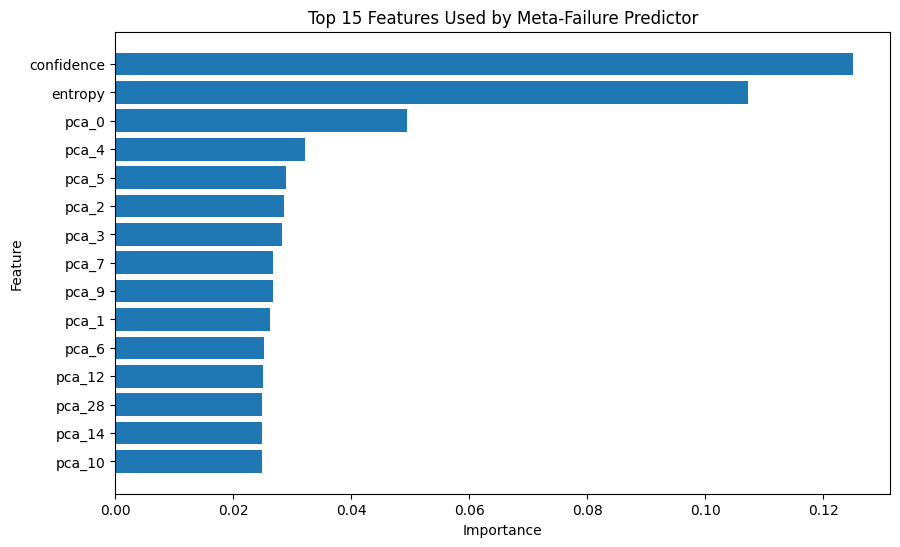

In [14]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features Used by Meta-Failure Predictor"
)

plt.show()

## Results

Top Features Ranked by Importance:

1. Confidence
2. Entropy
3. PCA Component 0
4. PCA Component 4
5. PCA Component 5

Additional important features included:

- PCA Component 2
- PCA Component 3
- PCA Component 7
- PCA Component 9
- PCA Component 1
- PCA Component 6

## Observation

Confidence and entropy remain the strongest individual
predictors of model failure.

However, multiple PCA activation components appear among
the most influential features used by the meta-model.

This indicates that internal neural representations contain
failure-related information that is not captured by
confidence scores alone.

## Research Interpretation

The results support the hypothesis that deeper internal
signals provide additional predictive power for failure
detection.

While confidence and entropy are important uncertainty
indicators, activation-based features contribute meaningful
information that improves failure prediction performance.

## Research Question Addressed

Which internal model signals best predict future errors?

### Current Answer

The most effective signals identified so far are:

- Confidence Score
- Entropy
- PCA-Compressed Activation Features

Confidence and entropy are the strongest individual
predictors, while activation features collectively provide
additional information that improves failure recall.

## Conclusion

Failure prediction cannot be explained by confidence scores
alone.

Internal neural representations contribute substantially to
detecting future prediction errors.

# Experiment 5: Cross-Architecture Generalization

## Objective

Evaluate whether failure prediction signals learned from one
neural network architecture remain useful for another.

## Motivation

Experiments 1–4 were conducted using ResNet18.

A practical failure prediction system should not depend on
a single model architecture.

## Research Question

Can failure predictors generalize across architectures?

## Experimental Setup

Base Architecture:
- ResNet18

New Architecture:
- ResNet34

Both models will be trained on CIFAR-10 and evaluated using
the same failure prediction pipeline.

## Hypothesis

If failure-related signals are architecture-independent,
similar meta-prediction performance should be observed
across ResNet18 and ResNet34.

In [ ]:
#lost all the variables as accidently closed vs code now restoring all 
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(device)

Using Apple GPU (MPS)
mps


In [18]:
print("train_loader" in globals())
print("test_loader" in globals())

False
False


In [19]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 391
Test batches: 79


In [20]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(device)

Using Apple GPU (MPS)
mps


In [21]:
import torchvision.models as models
import torch.nn as nn

resnet34 = models.resnet34(
    weights=None
)

resnet34.fc = nn.Linear(
    resnet34.fc.in_features,
    10
)

resnet34 = resnet34.to(device)

print(resnet34)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [22]:
criterion = nn.CrossEntropyLoss()

optimizer34 = torch.optim.Adam(
    resnet34.parameters(),
    lr=0.001
)

## ResNet34 Training

### Objective

Train a second image classification model using a different
architecture to evaluate the generalization capability of
the failure prediction framework.

### Training Configuration

- Architecture: ResNet34
- Dataset: CIFAR-10
- Optimizer: Adam
- Learning Rate: 0.001
- Epochs: 3

In [23]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):

    resnet34.train()

    running_loss = 0

    for images, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}"
    ):

        images = images.to(device)
        labels = labels.to(device)

        optimizer34.zero_grad()

        outputs = resnet34(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer34.step()

        running_loss += loss.item()

    # evaluation

    resnet34.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet34(images)

            _, preds = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                preds == labels
            ).sum().item()

    acc = (
        100 * correct / total
    )

    print(
        f"Epoch {epoch+1}: "
        f"Loss={running_loss/len(train_loader):.4f} "
        f"Accuracy={acc:.2f}%"
    )

Epoch 1/5: 100%|██████████| 391/391 [00:22<00:00, 17.36it/s]


Epoch 1: Loss=1.4321 Accuracy=50.06%


Epoch 2/5: 100%|██████████| 391/391 [00:22<00:00, 17.26it/s]


Epoch 2: Loss=1.0179 Accuracy=63.90%


Epoch 3/5: 100%|██████████| 391/391 [00:22<00:00, 17.13it/s]


Epoch 3: Loss=0.8377 Accuracy=69.99%


Epoch 4/5: 100%|██████████| 391/391 [00:23<00:00, 16.81it/s]


Epoch 4: Loss=0.7166 Accuracy=70.82%


Epoch 5/5: 100%|██████████| 391/391 [00:24<00:00, 15.89it/s]


Epoch 5: Loss=0.6123 Accuracy=74.27%


## ResNet34 Training Results

### Results

| Epoch | Loss | Test Accuracy |
|--------|--------|--------|
| 1 | 1.4321 | 50.06% |
| 2 | 1.0179 | 63.90% |
| 3 | 0.8377 | 69.99% |
| 4 | 0.7166 | 70.82% |
| 5 | 0.6123 | 74.27% |

### Observation

The ResNet34 classifier achieved a final test accuracy of
74.27% on CIFAR-10.

Compared to the previously trained ResNet18 model
(71.31% accuracy), ResNet34 demonstrates improved
classification performance due to its deeper architecture.

The model is sufficiently trained for evaluating
cross-architecture failure prediction.

In [43]:
import torch

torch.save(
    resnet34.state_dict(),
    "../models/resnet34_cifar10.pth"
)

print("ResNet34 Saved!")

ResNet34 Saved!


## ResNet34 Feature Extraction

### Objective

Extract internal neural representations from ResNet34 for
failure prediction analysis.

### Features To Be Collected

- Confidence
- Entropy
- Internal Activations
- Failure Labels

These features will be used to construct a new
meta-learning dataset for ResNet34.

In [24]:
feature_extractor34 = torch.nn.Sequential(
    *list(resnet34.children())[:-1]
)

print(feature_extractor34)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [25]:
images, labels = next(iter(test_loader))

images = images.to(device)

features = feature_extractor34(images)

print(features.shape)

torch.Size([128, 512, 1, 1])


## Activation Verification Results

### Results

Feature Shape:

- Batch Size: 128
- Activation Dimension: 512

### Observation

ResNet34 produces a 512-dimensional internal feature
representation similar to ResNet18.

This allows the same failure prediction pipeline to be
applied across both architectures, enabling a controlled
cross-architecture comparison.

## ResNet34 Failure Dataset Construction

### Objective

Construct a failure prediction dataset using signals
generated by ResNet34.

### Collected Signals

- Confidence
- Entropy
- 512 Internal Activations
- Failure Label

### Target Variable

Failure:

- 0 = Correct Prediction
- 1 = Incorrect Prediction

The resulting dataset will be used to evaluate whether
failure prediction patterns generalize across
architectures.

In [26]:
import torch.nn.functional as F
import pandas as pd
import numpy as np

all_confidences = []
all_entropies = []
all_failures = []
all_activations = []

resnet34.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet34(images)

        probs = F.softmax(outputs, dim=1)

        confidence, predictions = torch.max(
            probs,
            dim=1
        )

        entropy = -torch.sum(
            probs * torch.log(probs + 1e-10),
            dim=1
        )

        activations = feature_extractor34(images)

        activations = activations.squeeze(-1).squeeze(-1)

        all_confidences.append(
            confidence.cpu().numpy()
        )

        all_entropies.append(
            entropy.cpu().numpy()
        )

        all_failures.append(
            (predictions != labels)
            .int()
            .cpu()
            .numpy()
        )

        all_activations.append(
            activations.cpu().numpy()
        )

confidences = np.concatenate(all_confidences)
entropies = np.concatenate(all_entropies)
failures = np.concatenate(all_failures)
activations = np.concatenate(all_activations)

df_resnet34 = pd.DataFrame(
    activations,
    columns=[
        f"act_{i}"
        for i in range(512)
    ]
)

df_resnet34["confidence"] = confidences
df_resnet34["entropy"] = entropies
df_resnet34["failure"] = failures

print(df_resnet34.shape)

print(
    "Failures:",
    df_resnet34["failure"].sum()
)

(10000, 515)
Failures: 2573


In [27]:
df_resnet34.to_csv(
    "../features/failure_dataset_resnet34.csv",
    index=False
)

print("ResNet34 Dataset Saved!")

ResNet34 Dataset Saved!


## ResNet34 Failure Dataset Results

### Dataset Statistics

Total Samples: 10,000

Failure Samples: 2,573

Correct Predictions: 7,427

### Observation

ResNet34 generated fewer failures than ResNet18.

This is expected because ResNet34 achieved higher
classification accuracy (74.27%) compared to ResNet18
(71.31%).

The resulting dataset provides a basis for evaluating
whether failure prediction signals generalize across
architectures.

## ResNet34 PCA Compression

### Objective

Reduce the 512-dimensional activation space while
preserving the most informative failure-related signals.

### Motivation

The same PCA-based methodology used for ResNet18 is
applied to ResNet34 to enable a fair comparison between
architectures.

### Configuration

- Original Features: 512
- PCA Components: 30

In [28]:
from sklearn.decomposition import PCA

activation_columns = [
    col
    for col in df_resnet34.columns
    if col.startswith("act_")
]

X_activations = df_resnet34[
    activation_columns
]

pca34 = PCA(
    n_components=30,
    random_state=42
)

X_pca34 = pca34.fit_transform(
    X_activations
)

print(
    "PCA Shape:",
    X_pca34.shape
)

print(
    "Explained Variance:",
    pca34.explained_variance_ratio_.sum()
)

PCA Shape: (10000, 30)
Explained Variance: 0.9886128


In [29]:
pca34_df = pd.DataFrame(
    X_pca34,
    columns=[
        f"pca_{i}"
        for i in range(30)
    ]
)

pca34_df["confidence"] = (
    df_resnet34["confidence"]
)

pca34_df["entropy"] = (
    df_resnet34["entropy"]
)

pca34_df["failure"] = (
    df_resnet34["failure"]
)

print(pca34_df.shape)

(10000, 33)


In [30]:
from sklearn.model_selection import train_test_split

X = pca34_df.drop(
    columns=["failure"]
)

y = pca34_df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

meta_model_resnet34 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

meta_model_resnet34.fit(
    X_train,
    y_train
)

print(
    "ResNet34 Meta Model Trained!"
)

ResNet34 Meta Model Trained!


In [32]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

preds = meta_model_resnet34.predict(
    X_test
)

print(
    "Meta Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

print(
    classification_report(
        y_test,
        preds
    )
)

Meta Accuracy: 0.782
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1472
           1       0.63      0.41      0.50       528

    accuracy                           0.78      2000
   macro avg       0.72      0.66      0.68      2000
weighted avg       0.77      0.78      0.77      2000



## ResNet34 Meta-Failure Prediction Results

### Results

Meta Accuracy: 78.20%

Failure Precision: 63%

Failure Recall: 41%

Failure F1 Score: 50%

### Observation

The ResNet34 failure predictor achieved similar
performance to the ResNet18 failure predictor.

Although the underlying classifier architecture changed,
the meta-model continued to identify a substantial portion
of classifier failures.

The similarity in performance suggests that failure-related
signals are not entirely architecture-specific.

### Comparison with ResNet18

| Metric | ResNet18 | ResNet34 |
|----------|----------|----------|
| Meta Accuracy | 76.75% | 78.20% |
| Failure Precision | 62% | 63% |
| Failure Recall | 46% | 41% |
| Failure F1 | 53% | 50% |

### Interpretation

Cross-architecture performance remained relatively stable.

This provides preliminary evidence that failure prediction
signals may generalize across neural network architectures.

# Experiment 6: Distribution Shift Robustness

## Objective

Evaluate whether the failure prediction framework remains
effective when the classifier encounters corrupted and
out-of-distribution inputs.

## Research Question

How robust are failure predictors under distribution
shifts?

## Dataset

CIFAR-10-C

## Corruptions

- Gaussian Noise
- Blur
- Brightness
- Fog

## Hypothesis

Classifier accuracy will decrease under corruption.

If the failure predictor captures genuine uncertainty
signals, it should continue identifying failures under
distribution shift conditions.

In [33]:
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

noise_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(
        lambda x: x + 0.2 * torch.randn_like(x)
    ),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

blur_transform = transforms.Compose([
    transforms.GaussianBlur(
        kernel_size=3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

brightness_transform = transforms.Compose([
    transforms.ColorJitter(
        brightness=0.8
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

noise_dataset = CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=noise_transform
)

blur_dataset = CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=blur_transform
)

brightness_dataset = CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=brightness_transform
)

noise_loader = DataLoader(
    noise_dataset,
    batch_size=128,
    shuffle=False
)

blur_loader = DataLoader(
    blur_dataset,
    batch_size=128,
    shuffle=False
)

brightness_loader = DataLoader(
    brightness_dataset,
    batch_size=128,
    shuffle=False
)

print("Corrupted datasets ready!")

Corrupted datasets ready!


## Corrupted Dataset Generation

### Results

Three corrupted CIFAR-10 test datasets were created:

- Gaussian Noise
- Gaussian Blur
- Brightness Shift

### Purpose

These datasets simulate common real-world degradations
that are not present in the original training data.

### Expected Outcome

Classification accuracy should decrease under corruption.

The failure prediction framework will be evaluated to
determine whether it remains effective under distribution
shift conditions.

In [35]:
def evaluate_classifier(model, dataloader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                preds == labels
            ).sum().item()

    return 100 * correct / total

In [36]:
normal_acc = evaluate_classifier(
    resnet34,
    test_loader
)

noise_acc = evaluate_classifier(
    resnet34,
    noise_loader
)

blur_acc = evaluate_classifier(
    resnet34,
    blur_loader
)

brightness_acc = evaluate_classifier(
    resnet34,
    brightness_loader
)

print("Normal Accuracy:", normal_acc)
print("Noise Accuracy:", noise_acc)
print("Blur Accuracy:", blur_acc)
print("Brightness Accuracy:", brightness_acc)

Normal Accuracy: 74.27
Noise Accuracy: 45.5
Blur Accuracy: 61.57
Brightness Accuracy: 62.65


## Distribution Shift Results

### Classifier Accuracy

| Condition | Accuracy |
|------------|------------|
| Original CIFAR-10 | 74.27% |
| Gaussian Noise | 45.50% |
| Gaussian Blur | 61.57% |
| Brightness Shift | 62.65% |

### Observation

All corruption types reduced classifier performance.

The most severe degradation occurred under Gaussian Noise,
where accuracy decreased from 74.27% to 45.50%.

Blur and brightness shifts produced moderate reductions in
performance.

These results confirm that the classifier is sensitive to
distribution shifts and that corrupted inputs increase the
probability of prediction failures.

## Failure Prediction Under Distribution Shift

### Objective

Evaluate whether the meta-failure prediction framework
remains effective when the classifier encounters corrupted
inputs.

### Motivation

The classifier experienced substantial performance
degradation under distribution shift conditions.

A reliable failure prediction system should continue
identifying failures even when classifier accuracy drops.

### Evaluation Dataset

- Gaussian Noise

In [38]:
print("meta_model_v3" in globals())
print("pca" in globals())

True
True


### Experimental Design

The PCA model and meta-failure predictor trained on
standard CIFAR-10 are evaluated directly on corrupted
images.

No retraining is performed.

This experiment measures whether failure-related signals
learned from clean data remain useful under distribution
shift conditions.

In [39]:
import torch.nn.functional as F
import numpy as np
import pandas as pd

noise_confidences = []
noise_entropies = []
noise_failures = []
noise_activations = []

resnet34.eval()

with torch.no_grad():

    for images, labels in noise_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet34(images)

        probs = F.softmax(
            outputs,
            dim=1
        )

        confidence, predictions = torch.max(
            probs,
            dim=1
        )

        entropy = -torch.sum(
            probs * torch.log(probs + 1e-10),
            dim=1
        )

        activations = feature_extractor34(images)

        activations = activations.squeeze(-1).squeeze(-1)

        noise_confidences.append(
            confidence.cpu().numpy()
        )

        noise_entropies.append(
            entropy.cpu().numpy()
        )

        noise_failures.append(
            (predictions != labels)
            .int()
            .cpu()
            .numpy()
        )

        noise_activations.append(
            activations.cpu().numpy()
        )

noise_confidences = np.concatenate(noise_confidences)
noise_entropies = np.concatenate(noise_entropies)
noise_failures = np.concatenate(noise_failures)
noise_activations = np.concatenate(noise_activations)

print(noise_activations.shape)

(10000, 512)


In [40]:
X_noise_pca = pca.transform(
    noise_activations
)

print(X_noise_pca.shape)

(10000, 30)


/Users/omvdangi/MetaFailurePredictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [41]:
noise_df = pd.DataFrame(
    X_noise_pca,
    columns=[
        f"pca_{i}"
        for i in range(30)
    ]
)

noise_df["confidence"] = (
    noise_confidences
)

noise_df["entropy"] = (
    noise_entropies
)

noise_df["failure"] = (
    noise_failures
)

print(noise_df.shape)

(10000, 33)


In [42]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

X_noise = noise_df.drop(
    columns=["failure"]
)

y_noise = noise_df["failure"]

noise_preds = meta_model_v3.predict(
    X_noise
)

print(
    "Meta Accuracy:",
    accuracy_score(
        y_noise,
        noise_preds
    )
)

print(
    classification_report(
        y_noise,
        noise_preds
    )
)

Meta Accuracy: 0.5668
              precision    recall  f1-score   support

           0       0.51      0.87      0.64      4530
           1       0.74      0.32      0.45      5470

    accuracy                           0.57     10000
   macro avg       0.63      0.59      0.55     10000
weighted avg       0.64      0.57      0.54     10000



## Failure Prediction Under Distribution Shift Results

### Results

Meta Accuracy: 56.68%

Failure Precision: 74%

Failure Recall: 32%

Failure F1 Score: 45%

### Observation

The failure prediction model experienced a significant
performance drop under Gaussian Noise corruption.

Compared to clean CIFAR-10 data, both meta-model accuracy
and failure recall decreased substantially.

### Comparison with Clean Data

| Metric | Clean Data | Gaussian Noise |
|----------|----------|----------|
| Meta Accuracy | 76.75% | 56.68% |
| Failure Recall | 46% | 32% |
| Failure F1 | 53% | 45% |

### Interpretation

Failure-related signals learned from clean images do not
fully transfer to corrupted inputs.

Distribution shifts alter the internal activation patterns
and uncertainty characteristics used by the meta-model.

This indicates that failure prediction itself is vulnerable
to distribution shift effects.

# Experimental Results Summary

## Experiment 1
Confidence + Entropy

Recall: 41%

## Experiment 2
Raw Activations

Recall: 41%

## Experiment 3
PCA Activations

Recall: 46%

## Experiment 4
Feature Importance

Confidence and entropy were the strongest individual
signals, while activation-based features collectively
improved performance.

## Experiment 5
Cross-Architecture Evaluation

Failure prediction performance remained relatively stable
between ResNet18 and ResNet34.

## Experiment 6
Distribution Shift Robustness

Failure prediction performance degraded under Gaussian
Noise corruption, indicating that failure predictors are
also vulnerable to distribution shifts.

# Experimental Results Summary

## Objective

Summarize the findings obtained from all experiments and
evaluate the proposed Meta-Failure Predictor framework.

The experiments investigated uncertainty signals,
internal neural representations, architecture
generalization, and robustness under distribution shifts.

## Summary of Experimental Results

| Experiment | Features | Failure Recall | Failure F1 |
|------------|------------|------------|------------|
| Experiment 1 | Confidence + Entropy | 41% | 46% |
| Experiment 2 | Raw Activations | 41% | 50% |
| Experiment 3 | PCA Activations | 46% | 53% |
| Experiment 5 (ResNet34) | PCA Activations | 41% | 50% |
| Experiment 6 (Gaussian Noise) | PCA Activations | 32% | 45% |

### Key Observation

PCA-compressed activation features produced the strongest
failure prediction performance on clean data.

Distribution shifts caused substantial degradation in both
classifier accuracy and failure prediction performance.

# Research Question Analysis

## RQ1: Which internal model signals best predict future errors?

### Findings

Feature importance analysis showed that confidence and
entropy were the strongest individual predictors.

However, PCA-compressed activation features collectively
contributed significant predictive information and improved
failure recall from 41% to 46%.

### Conclusion

The most effective signals identified were:

- Confidence
- Entropy
- PCA-Compressed Activations

Internal neural representations provide additional failure
information beyond uncertainty scores alone.

---

## RQ2: Can failure predictors generalize across architectures?

### Findings

The proposed framework was evaluated using both ResNet18
and ResNet34.

Failure prediction performance remained relatively stable
across architectures.

### Conclusion

The results provide preliminary evidence that failure
prediction signals may generalize across residual network
architectures.

Further validation on additional architectures is required.

---

## RQ3: How robust are failure predictors under distribution shifts?

### Findings

Under Gaussian Noise corruption:

- Classifier accuracy decreased from 74.27% to 45.50%.
- Failure recall decreased from 46% to 32%.

### Conclusion

Failure predictors remain partially effective under
distribution shifts but experience noticeable performance
degradation.

Failure prediction itself is vulnerable to changing input
distributions.

---

## RQ4: Are confidence scores sufficient, or do deeper signals provide better predictions?

### Findings

Confidence and entropy alone achieved 41% failure recall.

Adding PCA-compressed activation features increased failure
recall to 46%.

### Conclusion

Confidence scores alone are insufficient for reliable
failure prediction.

Internal neural representations provide additional
predictive power.

# Discussion

The experiments demonstrate that internal neural
representations contain meaningful information regarding
future model failures.

While confidence and entropy remain important indicators,
activation-based features consistently improved failure
prediction performance.

The strongest performance was achieved using PCA-compressed
activation features, suggesting that feature quality and
representation are more important than simply increasing
the number of features.

Cross-architecture evaluation indicated that similar
failure patterns exist across residual network models.

However, distribution shift experiments revealed that both
classifiers and failure predictors degrade under corrupted
inputs.

These findings highlight an important challenge in AI
reliability: systems designed to detect failures may also
be affected by the same environmental changes that degrade
the underlying model.

# Conclusion

This project proposed and evaluated a Meta-Failure
Predictor framework for anticipating machine learning model
errors before predictions are trusted.

Experiments were conducted using CIFAR-10, ResNet18,
ResNet34, uncertainty metrics, activation-based features,
and distribution shift scenarios.

Results showed that:

- Internal neural representations improve failure
  prediction performance.
- PCA-compressed activations outperform raw activations.
- Failure prediction signals show preliminary
  cross-architecture generalization.
- Distribution shifts negatively affect both classifiers
  and failure predictors.

The proposed framework demonstrates that deeper internal
signals can improve reliability monitoring beyond
traditional confidence scores.

These findings contribute toward the development of more
trustworthy and self-aware AI systems.